# 02 Train Stable and Baseline Models

Ovaj notebook trenira dva modela nad istim derivative dataset-om `(x, xdot)`:

- **Stable ICNN dynamics**: nominalni MLP `fhat(x)` se projektuje tako da zadovolji Lyapunov decrease uslov za naučenu ICNN Lyapunov funkciju `V(x)`.
- **Baseline MLP**: običan MLP koji direktno uči `x -> xdot`, bez stabilnosnog ograničenja.

Cilj nije samo da loss bude mali, nego da vidimo da stabilni model daje vektorsko polje koje po konstrukciji poštuje uslov:

```text
grad V(x)^T f(x) + alpha V(x) <= 0
```

## 1. Importi, kernel i konfiguracija

Za ovaj notebook je potreban PyTorch. Ako dobiješ grešku pri importu, promeni kernel u **Python (masters_torch312)**.

Najvažniji parametri za menjanje su u ovoj ćeliji:

- `SYSTEM_NAME`, `N_TRAIN`, `N_TEST`: koji dataset se učitava iz `data/cache/`.
- `EPOCHS`, `BATCH_SIZE`, `LEARNING_RATE`: parametri treninga.
- `HIDDEN`, `DEPTH`: arhitektura nominalnog i baseline MLP-a.
- `LYAPUNOV_HIDDEN`, `LYAPUNOV_EPS`, `ALPHA`: parametri Lyapunov/ICNN dela stabilnog modela.

Pre pokretanja ovog notebooka pokreni `01_generate_data.ipynb` za isti `SYSTEM_NAME`, `N_TRAIN`, `N_TEST` i `SEED`.

In [40]:
from pathlib import Path
import sys
import numpy as np

# Let the notebook import the local package whether Jupyter starts in the
# repository root or inside the notebooks/ directory.
REPO_ROOT = Path.cwd() if (Path.cwd() / "stable_icnn_physics").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Jupyter kernels keep imported modules in memory. If package code changed
# while the kernel was alive, clear the local package so imports see the
# latest files from disk.
for module_name in list(sys.modules):
    if module_name == "stable_icnn_physics" or module_name.startswith("stable_icnn_physics."):
        del sys.modules[module_name]

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "PyTorch is not installed in this notebook kernel. "
        "In VS Code/Jupyter, switch the kernel to 'Python (masters_torch312)', "
        "or install dependencies with: pip install -r requirements.txt"
    ) from exc
except ImportError as exc:
    raise ImportError(
        "PyTorch exists in this kernel but failed to load. "
        "This usually means the selected conda env is broken. "
        "Switch the notebook kernel to 'Python (masters_torch312)'."
    ) from exc

from stable_icnn_physics import BaselineDynamicsMLP
from stable_icnn_physics.data import dataset_path, load_dataset, tensor_dataset
from stable_icnn_physics.models import build_stable_model
from stable_icnn_physics.train import evaluate_derivative_mse, train_derivative_model
from stable_icnn_physics.plotting import plot_loss

CACHE_DIR = REPO_ROOT / "data/cache"
OUTPUT_DIR = REPO_ROOT / "outputs"
SEED = 0
#SYSTEM_NAME = "oscillator"
# For Van der Pol data generated in 01_generate_data.ipynb, use:
SYSTEM_NAME = "vanderpol_mu1"
N_TRAIN = 4000
N_TEST = 1000

EPOCHS = 200
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
HIDDEN = 100
DEPTH = 2
LYAPUNOV_HIDDEN = 60
LYAPUNOV_EPS = 0.01
ALPHA = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Torch:", torch.__version__)
print("Device:", DEVICE)

Repo root: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN
Torch: 2.9.1+cpu
Device: cpu


## 2. Učitavanje i brza provera dataset-a

Učitavamo train/test fajlove napravljene u prethodnom notebooku. Svaki uzorak je par:

\[
(x, \dot{x}).
\]

Za oscilator je `x = [position, velocity]`, a `xdot = [velocity, acceleration]`. Za klatno je `x = [theta, omega]`.

In [41]:
train_path = dataset_path(CACHE_DIR, SYSTEM_NAME, "train", N_TRAIN, SEED)
test_path = dataset_path(CACHE_DIR, SYSTEM_NAME, "test", N_TEST, SEED)

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        "Dataset files were not found. Run notebooks/01_generate_data.ipynb first "
        f"with SYSTEM_NAME={SYSTEM_NAME!r}, N_TRAIN={N_TRAIN}, N_TEST={N_TEST}, SEED={SEED}."
    )

x_train, y_train = load_dataset(train_path)
x_test, y_test = load_dataset(test_path)
train_ds = tensor_dataset(x_train, y_train)
test_ds = tensor_dataset(x_test, y_test)
dim = x_train.shape[1]

print("train:", x_train.shape, y_train.shape)
print("test: ", x_test.shape, y_test.shape)
print("state dim:", dim)
print("x mean/std:", x_train.mean(axis=0), x_train.std(axis=0))
print("xdot mean/std:", y_train.mean(axis=0), y_train.std(axis=0))

train: (4000, 2) (4000, 2)
test:  (1000, 2) (1000, 2)
state dim: 2
x mean/std: [-0.02028993  0.00052476] [1.7293757 2.3260813]
xdot mean/std: [ 0.00052476 -0.0425271 ] [2.3260813 7.9565716]


## 3. Vizuelna provera podataka

Pre treninga je korisno pogledati šta mreža uči. Donji grafici prikazuju:

- raspodelu stanja u faznom prostoru,
- nekoliko strelica stvarnog vektorskog polja `xdot = f(x)`,
- histogram komponenti izvoda.

Ako su stanja ili izvodi čudno skalirani, trening će obično biti teži.

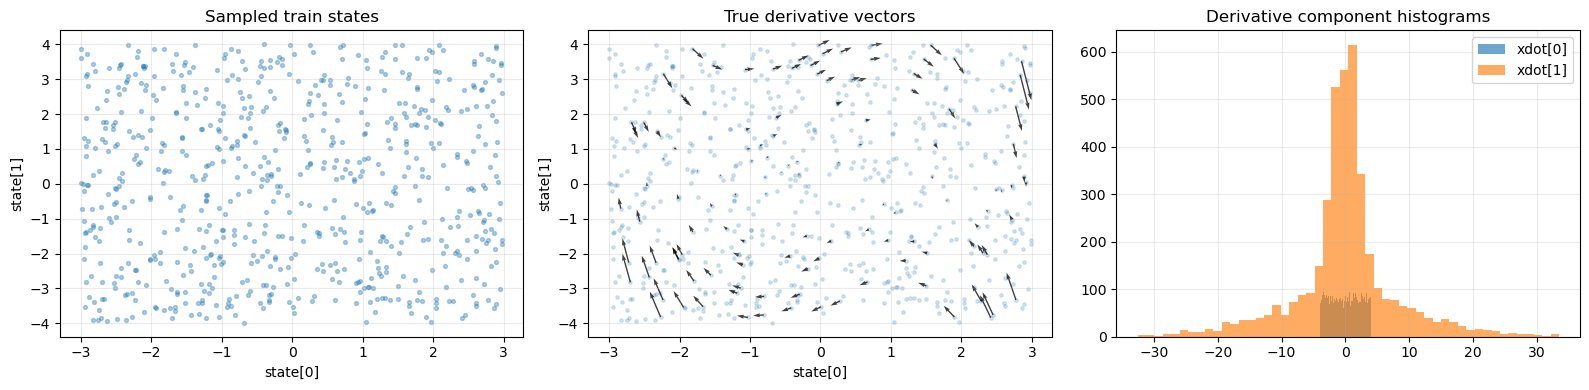

In [42]:
import matplotlib.pyplot as plt

sample_count = min(700, len(x_train))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(x_train), size=sample_count, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(x_train[idx, 0], x_train[idx, 1], s=8, alpha=0.35)
axes[0].set_xlabel("state[0]")
axes[0].set_ylabel("state[1]")
axes[0].set_title("Sampled train states")
axes[0].grid(alpha=0.25)

q_idx = idx[:120]
axes[1].scatter(x_train[idx, 0], x_train[idx, 1], s=6, alpha=0.18)
axes[1].quiver(
    x_train[q_idx, 0],
    x_train[q_idx, 1],
    y_train[q_idx, 0],
    y_train[q_idx, 1],
    angles="xy",
    scale_units="xy",
    scale=25,
    width=0.003,
    alpha=0.75,
)
axes[1].set_xlabel("state[0]")
axes[1].set_ylabel("state[1]")
axes[1].set_title("True derivative vectors")
axes[1].grid(alpha=0.25)

axes[2].hist(y_train[:, 0], bins=50, alpha=0.65, label="xdot[0]")
axes[2].hist(y_train[:, 1], bins=50, alpha=0.65, label="xdot[1]")
axes[2].set_title("Derivative component histograms")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()

## 4. Kreiranje modela

Stabilni model ima dva dela:

1. `fhat`: običan MLP koji predlaže dinamiku.
2. `V`: pozitivno definitna ICNN Lyapunov funkcija.

`StableDynamics` zatim projektuje `fhat` na poluprostor u kome je Lyapunov funkcija opadajuća. Baseline MLP ima sličan kapacitet, ali nema projekciju niti Lyapunov garanciju.

In [43]:
stable_model = build_stable_model(
    dim=dim,
    hidden=HIDDEN,
    depth=DEPTH,
    lyapunov_hidden=LYAPUNOV_HIDDEN,
    lyapunov_eps=LYAPUNOV_EPS,
    alpha=ALPHA,
)

baseline_model = BaselineDynamicsMLP(dim=dim, hidden=HIDDEN, depth=DEPTH)

stable_params = sum(p.numel() for p in stable_model.parameters())
baseline_params = sum(p.numel() for p in baseline_model.parameters())

print(stable_model)
print("stable parameters:", stable_params)
print("baseline parameters:", baseline_params)

StableDynamics(
  (fhat): NominalMLP(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=100, bias=True)
      (1): ReLU()
      (2): Linear(in_features=100, out_features=100, bias=True)
      (3): ReLU()
      (4): Linear(in_features=100, out_features=2, bias=True)
    )
  )
  (V): PositiveDefiniteLyapunov(
    (icnn): ICNN(
      (input_weights): ParameterList(
          (0): Parameter containing: [torch.float32 of size 60x2]
          (1): Parameter containing: [torch.float32 of size 60x2]
          (2): Parameter containing: [torch.float32 of size 1x2]
      )
      (hidden_weights): ParameterList(
          (0): Parameter containing: [torch.float32 of size 60x60]
          (1): Parameter containing: [torch.float32 of size 1x60]
      )
      (biases): ParameterList(
          (0): Parameter containing: [torch.float32 of size 60]
          (1): Parameter containing: [torch.float32 of size 60]
          (2): Parameter containing: [torch.float32 of size 1]
      )
 

## 5. Trening stabilnog modela

Loss je običan MSE između predviđenog i tačnog izvoda:

```text
L = (1 / N) * sum_i || f_theta(x_i) - xdot_i ||_2^2
```

Stabilnost se ne dodaje kao soft penalty u loss; ona je ugrađena u samu forward funkciju modela kroz projekciju.

In [44]:
stable_history = train_derivative_model(
    stable_model,
    train_ds,
    test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    checkpoint_path=OUTPUT_DIR / f"{SYSTEM_NAME}_stable.pt",
    print_every=max(1, EPOCHS // 8),
)

epoch=0001 train_mse=30.4616 test_mse=22.6445
epoch=0025 train_mse=0.954268 test_mse=0.828043
epoch=0050 train_mse=0.188718 test_mse=0.166755
epoch=0075 train_mse=0.0634825 test_mse=0.0590675
epoch=0100 train_mse=0.0358736 test_mse=0.0370054
epoch=0125 train_mse=0.0254829 test_mse=0.0269635
epoch=0150 train_mse=0.0203314 test_mse=0.0227777
epoch=0175 train_mse=0.017608 test_mse=0.0215078
epoch=0200 train_mse=0.0157499 test_mse=0.019225


## 6. Trening baseline MLP-a

Baseline model je važan za empirijsko poređenje. Često može imati dobar one-step derivative MSE, ali pri rollout-u ume da ode u nestabilne ili fizički loše trajektorije.

In [45]:
baseline_history = train_derivative_model(
    baseline_model,
    train_ds,
    test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    checkpoint_path=OUTPUT_DIR / f"{SYSTEM_NAME}_baseline.pt",
    print_every=max(1, EPOCHS // 8),
)

epoch=0001 train_mse=30.0516 test_mse=22.7737
epoch=0025 train_mse=0.652466 test_mse=0.553249
epoch=0050 train_mse=0.105455 test_mse=0.0838963
epoch=0075 train_mse=0.0351503 test_mse=0.0296776
epoch=0100 train_mse=0.0159789 test_mse=0.014297
epoch=0125 train_mse=0.0094598 test_mse=0.00713816
epoch=0150 train_mse=0.00555633 test_mse=0.00491708
epoch=0175 train_mse=0.00400533 test_mse=0.00489988
epoch=0200 train_mse=0.00377818 test_mse=0.00465623


## 7. Loss krive

Ovo je osnovna provera fitovanja `x -> xdot`. Stabilni model može imati nešto veći derivative MSE od baseline-a, jer mu projekcija ograničava vektorsko polje. Važan deo poređenja dolazi kasnije kroz rollout i stabilnosnu dijagnostiku.

stable test MSE:   0.01922501754760742
baseline test MSE: 0.004656230926513672


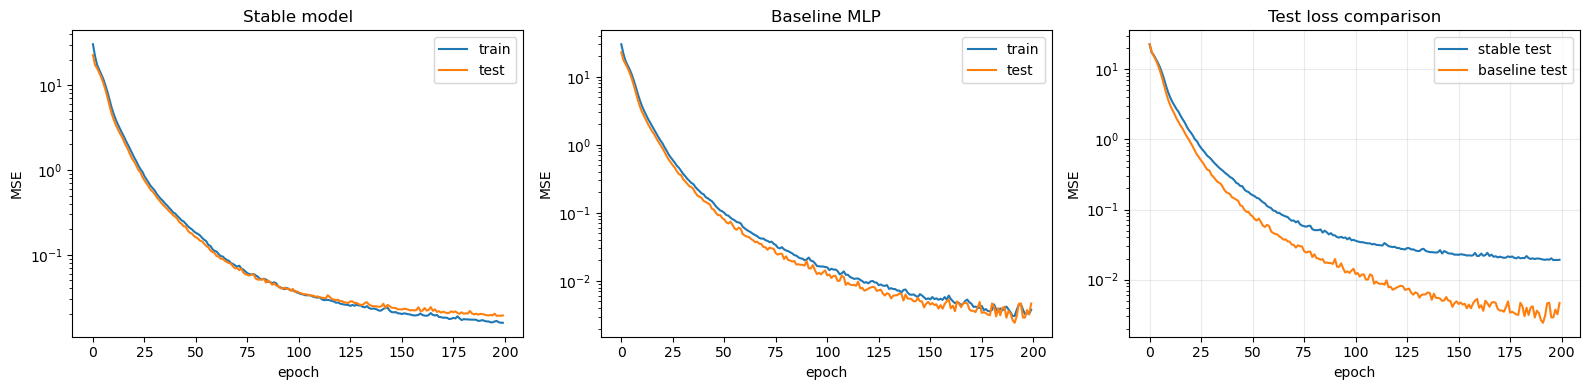

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_loss(stable_history, ax=axes[0], title="Stable model")
plot_loss(baseline_history, ax=axes[1], title="Baseline MLP")

axes[2].plot(stable_history.test_loss, label="stable test")
axes[2].plot(baseline_history.test_loss, label="baseline test")
axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("MSE")
axes[2].set_title("Test loss comparison")
axes[2].legend()
axes[2].grid(alpha=0.25)
plt.tight_layout()

stable_test_mse = evaluate_derivative_mse(stable_model, test_ds, device=DEVICE)
baseline_test_mse = evaluate_derivative_mse(baseline_model, test_ds, device=DEVICE)
print("stable test MSE:  ", stable_test_mse)
print("baseline test MSE:", baseline_test_mse)

## 8. Predikcije izvoda na test skupu

Scatter grafici porede tačne i predviđene komponente izvoda. Idealno, tačke leže na dijagonali.

Ovo je lokalna metrika: govori koliko dobro model pogađa vektorsko polje u pojedinačnim tačkama, ali ne garantuje da će dugoročna simulacija biti dobra.

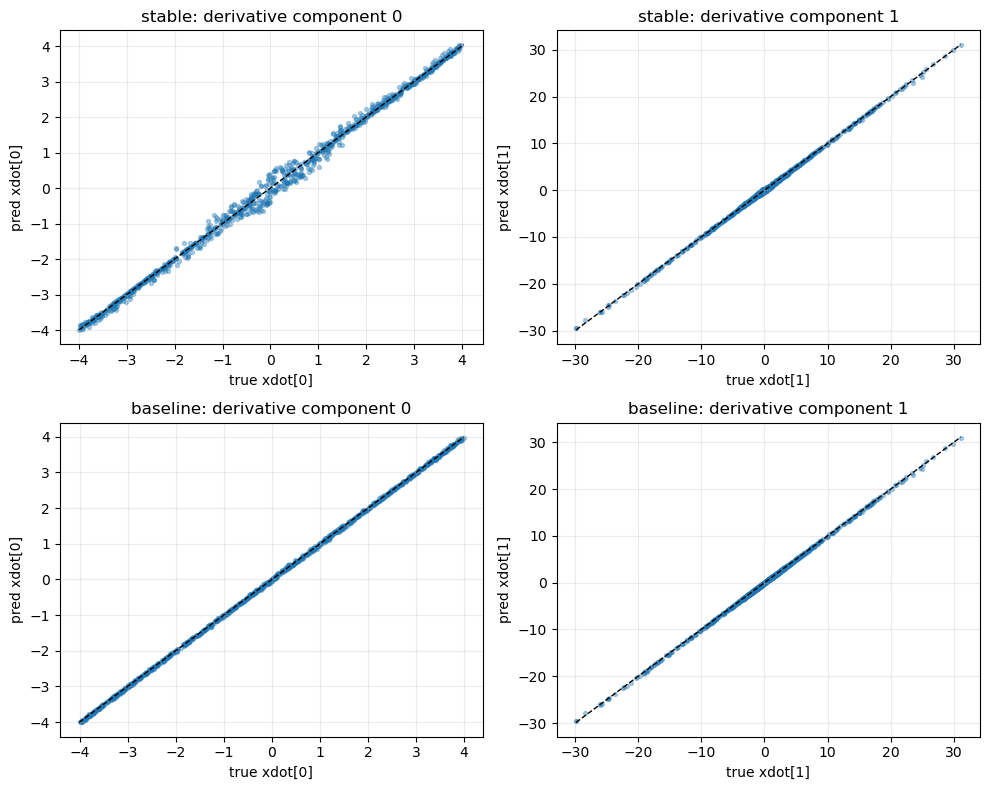

In [47]:
def predict_numpy(model, x_np, batch_size=2048):
    model.eval()
    preds = []
    with torch.enable_grad():
        for start in range(0, len(x_np), batch_size):
            xb = torch.from_numpy(x_np[start:start + batch_size]).to(DEVICE)
            preds.append(model(xb).detach().cpu().numpy())
    return np.concatenate(preds, axis=0)

stable_pred = predict_numpy(stable_model, x_test)
baseline_pred = predict_numpy(baseline_model, x_test)

fig, axes = plt.subplots(2, dim, figsize=(5 * dim, 8), squeeze=False)
models_to_plot = [("stable", stable_pred), ("baseline", baseline_pred)]

for row, (name, pred) in enumerate(models_to_plot):
    for j in range(dim):
        ax = axes[row, j]
        ax.scatter(y_test[:, j], pred[:, j], s=8, alpha=0.35)
        lo = min(y_test[:, j].min(), pred[:, j].min())
        hi = max(y_test[:, j].max(), pred[:, j].max())
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
        ax.set_xlabel(f"true xdot[{j}]")
        ax.set_ylabel(f"pred xdot[{j}]")
        ax.set_title(f"{name}: derivative component {j}")
        ax.grid(alpha=0.25)

plt.tight_layout()

## 9. Vizuelno poređenje naučenog vektorskog polja

Za 2D sisteme možemo nacrtati strelice predviđene dinamike preko istog domena kao train podaci. Kod oscilatora, dobro naučeno polje treba da liči na rotaciju ka centru sa prigušenjem.

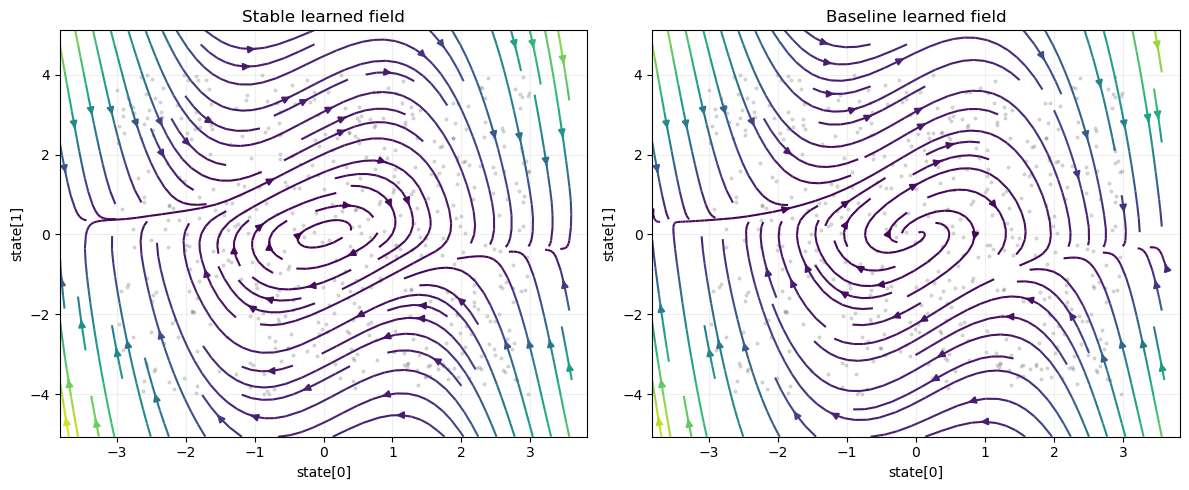

In [48]:
if dim != 2:
    print("Vector-field visualization is only implemented for 2D systems.")
else:
    x_min, x_max = np.percentile(x_train[:, 0], [1, 99])
    y_min, y_max = np.percentile(x_train[:, 1], [1, 99])
    pad_x = 0.15 * (x_max - x_min)
    pad_y = 0.15 * (y_max - y_min)
    xs = np.linspace(x_min - pad_x, x_max + pad_x, 25)
    ys = np.linspace(y_min - pad_y, y_max + pad_y, 25)
    gx, gy = np.meshgrid(xs, ys)
    grid = np.stack([gx.ravel(), gy.ravel()], axis=1).astype(np.float32)

    true_grid = np.zeros_like(grid)
    # For oscillator datasets, xdot[0] = velocity = state[1]. For a generic cached dataset,
    # nearest-neighbor reconstruction is avoided; this plot uses model predictions plus train samples.
    stable_grid = predict_numpy(stable_model, grid)
    baseline_grid = predict_numpy(baseline_model, grid)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, title, vec in [
        (axes[0], "Stable learned field", stable_grid),
        (axes[1], "Baseline learned field", baseline_grid),
    ]:
        speed = np.linalg.norm(vec, axis=1).reshape(gx.shape)
        ax.streamplot(gx, gy, vec[:, 0].reshape(gx.shape), vec[:, 1].reshape(gx.shape), color=speed, cmap="viridis")
        ax.scatter(x_train[:500, 0], x_train[:500, 1], s=4, alpha=0.12, color="black")
        ax.set_xlabel("state[0]")
        ax.set_ylabel("state[1]")
        ax.set_title(title)
        ax.grid(alpha=0.2)
    plt.tight_layout()

## 10. Lyapunov dijagnostika stabilnog modela

Za stabilni model proveravamo vrednost:

```text
grad V(x)^T f(x) + alpha V(x)
```

Zbog projekcije ova vrednost treba da bude `<= 0`, uz malu numeričku toleranciju. Ovo nije dodatni trening loss, nego posledica arhitekture modela.

max(gradV*f + alpha*V): 3.0100346e-06
mean: -22.967005
fraction <= 1e-5: 1.0
min V: 0.0024698277 max V: 51.858303


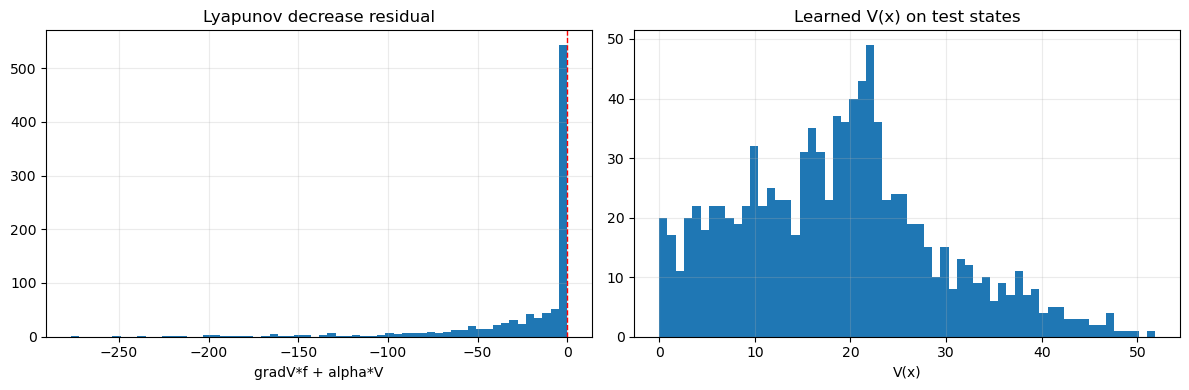

In [49]:
stable_model.eval()
check_x = torch.from_numpy(x_test[: min(1024, len(x_test))]).to(DEVICE)
with torch.enable_grad():
    decrease = stable_model.lyapunov_decrease(check_x).detach().cpu().numpy().ravel()
    V_values = stable_model.V(check_x.detach().requires_grad_(True)).detach().cpu().numpy().ravel()

print("max(gradV*f + alpha*V):", decrease.max())
print("mean:", decrease.mean())
print("fraction <= 1e-5:", np.mean(decrease <= 1e-5))
print("min V:", V_values.min(), "max V:", V_values.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(decrease, bins=60)
axes[0].axvline(0.0, color="red", lw=1, ls="--")
axes[0].set_title("Lyapunov decrease residual")
axes[0].set_xlabel("gradV*f + alpha*V")
axes[0].grid(alpha=0.25)

axes[1].hist(V_values, bins=60)
axes[1].set_title("Learned V(x) on test states")
axes[1].set_xlabel("V(x)")
axes[1].grid(alpha=0.25)
plt.tight_layout()

## 11. Sačuvani rezultati

Checkpoint fajlovi su sačuvani u `outputs/` i koristiće ih `03_evaluate_results.ipynb` za RK4 rollout poređenje.

Ako promeniš sistem ili hiperparametre, ponovo pokreni trening i zatim evaluaciju.

In [50]:
print("stable checkpoint:  ", OUTPUT_DIR / f"{SYSTEM_NAME}_stable.pt")
print("baseline checkpoint:", OUTPUT_DIR / f"{SYSTEM_NAME}_baseline.pt")

stable checkpoint:   /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/outputs/vanderpol_mu1_stable.pt
baseline checkpoint: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/outputs/vanderpol_mu1_baseline.pt
